In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

In [2]:
raw_data = pd.read_csv('C:/Users/molszo/Documents/DATA_SETS/titanic/train.csv')

In [3]:
data = raw_data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked'], axis=1)

In [4]:
data['Sex'] = (data['Sex'] == 'male').astype(float)

In [5]:
data = data.replace(np.nan, round(np.mean(data['Age'])))

In [6]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,1.0,22.0,1,0,7.2500
1,1,1,0.0,38.0,1,0,71.2833
2,1,3,0.0,26.0,0,0,7.9250
3,1,1,0.0,35.0,1,0,53.1000
4,0,3,1.0,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,1.0,27.0,0,0,13.0000
887,1,1,0.0,19.0,0,0,30.0000
888,0,3,0.0,30.0,1,2,23.4500
889,1,1,1.0,26.0,0,0,30.0000


In [7]:
for c in data.columns:
    if type(data[c][0]) == np.int64:
        data[c] = data[c].astype(float)

In [8]:
data['Survived'] = data['Survived'].astype(int)

In [9]:
# z norm
for c in data.columns[data.columns != 'Survived']:
    mean = np.mean(data[c])
    std = np.std(data[c])
    data[c] = (data[c] - mean)/std

In [47]:
torch_data = torch.tensor(np.array(data.iloc[:, 1:])).float()
torch_targets = torch.tensor(np.array(data.iloc[:, 0])).float()
torch_targets.unsqueeze_(axis=1);

In [48]:
torch_data

tensor([[ 0.8274,  0.7377, -0.5971,  0.4328, -0.4737, -0.5024],
        [-1.5661, -1.3556,  0.6342,  0.4328, -0.4737,  0.7868],
        [ 0.8274, -1.3556, -0.2893, -0.4745, -0.4737, -0.4889],
        ...,
        [ 0.8274, -1.3556,  0.0186,  0.4328,  2.0089, -0.1763],
        [-1.5661,  0.7377, -0.2893, -0.4745, -0.4737, -0.0444],
        [ 0.8274,  0.7377,  0.1725, -0.4745, -0.4737, -0.4924]])

In [49]:
x_train, x_test, y_train, y_test = train_test_split(torch_data, torch_targets, test_size = .1)

In [50]:
train_data_set = TensorDataset(x_train, y_train)
test_data_set = TensorDataset(x_test, y_test)

In [51]:
train_loader = DataLoader(train_data_set, batch_size=12, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data_set, batch_size=test_data_set.tensors[0].shape[0], shuffle=True)

In [52]:
for x,y in train_loader:
    print(x)
    break

tensor([[-1.5661, -1.3556,  0.0186,  0.4328, -0.4737,  0.3958],
        [ 0.8274,  0.7377, -0.3662, -0.4745, -0.4737, -0.5024],
        [-1.5661,  0.7377,  0.0955,  0.4328, -0.4737,  0.3986],
        [-0.3694, -1.3556, -0.2893,  0.4328,  0.7676, -0.1249],
        [-1.5661, -1.3556,  0.7111,  0.4328,  0.7676,  1.5842],
        [ 0.8274, -1.3556, -1.0588, -0.4745, -0.4737, -0.4924],
        [ 0.8274, -1.3556, -1.5974,  2.2475,  2.0089, -0.0867],
        [-1.5661,  0.7377,  0.0186, -0.4745, -0.4737, -0.1138],
        [ 0.8274,  0.7377,  0.2494, -0.4745, -0.4737, -0.4571],
        [-1.5661, -1.3556, -0.5971, -0.4745,  0.7676,  0.4590],
        [ 0.8274, -1.3556,  0.0186, -0.4745, -0.4737, -0.4964],
        [ 0.8274,  0.7377,  0.6342, -0.4745, -0.4737, -0.4894]])


In [22]:
class TitanicModel(nn.Module):
    def __init__(self):
        super(TitanicModel, self).__init__()
        self.input = nn.Linear(6, 16)
        self.fc1 = nn.Linear(16, 16)
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 16)
        self.output = nn.Linear(16, 1)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        out = self.input(x)
        out = self.relu(out)
        
        out = self.fc1(out)
        out = self.relu(out)
        
        out = self.fc2(out)
        out = self.relu(out)
        
        out = self.fc3(out)
        out = self.relu(out)
        
        out = self.output(out)
        return out

In [23]:
model = TitanicModel()
optimizer = torch.optim.Adam(model.parameters(), lr=.001)
loss_fn = nn.BCEWithLogitsLoss()
# torch.set_default_dtype(torch.float64)

In [24]:
num_of_params = 0
for n,p in model.named_parameters():
    if 'weight' in n:
        num_of_params = num_of_params + p.numel()

In [95]:
for n,p in model.named_parameters():
    if 'weight' in n:
        print(n,p)

input.weight Parameter containing:
tensor([[-0.2766,  0.0037, -0.1007,  0.0911, -0.0771,  0.0697],
        [ 0.0161,  0.0789,  0.1645,  0.3186, -0.0793,  0.2217],
        [ 0.1719, -0.1972,  0.3145, -0.0269,  0.0100, -0.3918],
        [ 0.1758,  0.2169,  0.0574, -0.0400, -0.1390, -0.0796],
        [ 0.2844,  0.0774,  0.0234,  0.0679,  0.2713,  0.0056],
        [ 0.2542,  0.2368, -0.3353, -0.3235, -0.2743,  0.1611],
        [-0.2752, -0.3421, -0.2850, -0.2538, -0.2562, -0.2735],
        [-0.1601,  0.0784,  0.3481, -0.2611,  0.3856,  0.2897],
        [ 0.3782, -0.2453,  0.2949,  0.1131, -0.3426, -0.2929],
        [ 0.1691,  0.2676, -0.1614,  0.2550, -0.2760, -0.3774],
        [ 0.3039, -0.3395,  0.3890, -0.0084, -0.0482, -0.2508],
        [ 0.0664,  0.0189,  0.2297, -0.2379, -0.1864, -0.1329],
        [ 0.3971, -0.2820, -0.1069, -0.1869,  0.0069,  0.3706],
        [ 0.1852,  0.0412, -0.0194, -0.3372, -0.1665, -0.0874],
        [-0.0162,  0.0293,  0.0368,  0.2390, -0.2728, -0.2135],
     

In [25]:
def get_L(model, lmbd):
    L1 = torch.tensor(0.,requires_grad=True)
    for n,p in model.named_parameters():
        if 'weight' in n:
            L1 = L1 + torch.sum( torch.abs(p) )
    L2  = torch.tensor(0.,requires_grad=True)
    for n,p in model.named_parameters():
        if 'weight' in n:
            L2 = L2 + torch.sum(p**2)
        
    return (L1/num_of_params)*lmbd + (L2/num_of_params)*lmbd

In [17]:
def train(epochs, lmbd):
    loss_per_epoch = []
    acc_per_epoch = []
    
    test_loss_per_epoch = []
    test_acc_per_epoch = []
    for e in range(epochs):
        loss_per_batch = []
        acc_per_batch = []
        for x,y in train_loader:
            outputs = model(x)
            loss = loss_fn(outputs, y)
            loss = loss + get_L(model, lmbd)
            loss_per_batch.append(loss.item())
            
            acc_per_batch.append( torch.mean( ((torch.sigmoid(outputs) > .5) == y).float() ).detach() )
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        acc_per_epoch.append(np.mean(acc_per_batch))
        loss_per_epoch.append(np.mean(loss_per_batch))
        
        with torch.no_grad():
            x,y = next(iter(test_loader))
            outputs = model(x)
            loss = loss_fn(outputs, y)
            test_loss_per_epoch.append(loss.item())    
            test_acc_per_epoch.append( torch.mean( ((torch.sigmoid(outputs) > .5) == y).float() ).detach() )
        
    return loss_per_epoch, acc_per_epoch, test_loss_per_epoch, test_acc_per_epoch

In [18]:
loss, acc, test_loss, test_acc = train(200, .01)

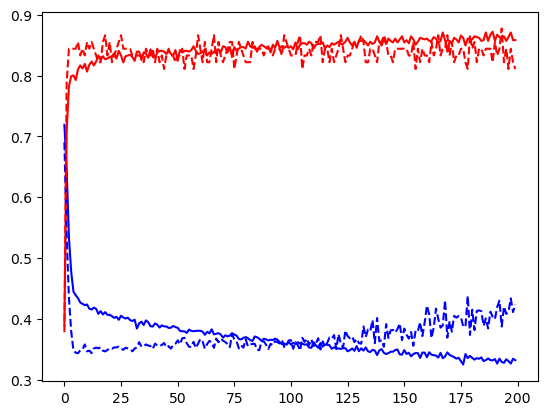

In [19]:
plt.plot(loss, 'b-')
plt.plot(acc, 'r-')
plt.plot(test_loss, 'b--')
plt.plot(test_acc, 'r--')

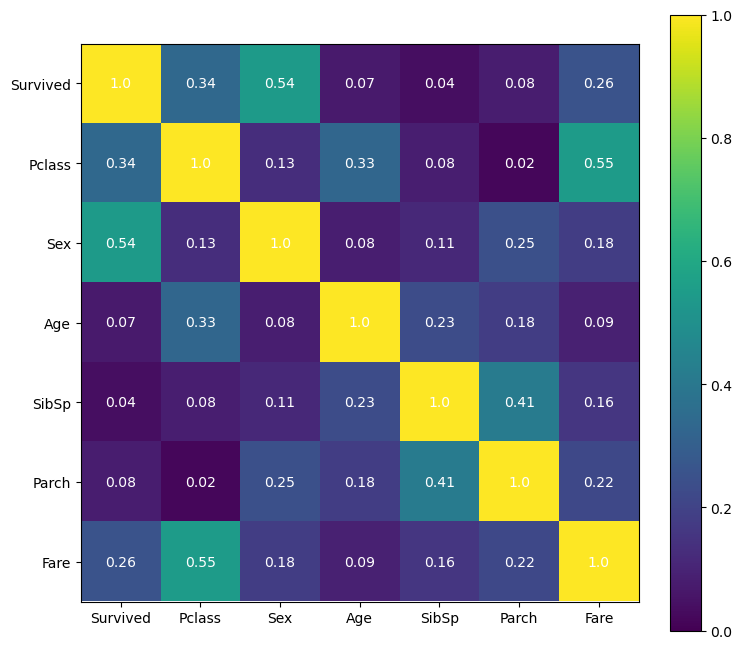

In [56]:
import scipy.stats as stats
corr = np.abs(np.corrcoef(data.T))

fig, ax = plt.subplots(figsize=(8,8))
im = ax.imshow(corr, vmin=0 , vmax=1)
fig.colorbar(im, orientation='vertical', fraction = 0.05)

ax.set_xticks(np.arange(7))
ax.set_yticks(np.arange(7))

ax.set_xticklabels(data.columns)
ax.set_yticklabels(data.columns)

for i in range(len(data.columns)):
    for j in range(len(data.columns)):
        ax.text(j, i, round(corr[i, j], 2), ha="center", va="center", color="white")

plt.show()

In [55]:
corr[0]

array([1.        , 0.33848104, 0.54335138, 0.07065723, 0.0353225 ,
       0.08162941, 0.25730652])

In [81]:
stats.pearsonr(np.array(data.iloc[:,0]), np.array(data.iloc[:,3]))

PearsonRResult(statistic=-0.07065723128500329, pvalue=0.0349646988145343)

In [91]:
r = np.corrcoef( (np.array(data.iloc[:,0]), np.array(data.iloc[:,2])) )[0,1]

In [92]:
num = r*(len(data)-2)**(1/2)
den = (1 - r**2)**(1/2)

In [93]:
num/den

-19.297816550123336

In [94]:
(1 - (stats.t.cdf(abs(num/den), len(data)-2)))*2

0.0